# Datos
Esto lo estoy retomando el 9 de septiembre del 2026, porque otra vez ya se me olvidó en qué chingados estaba trabajando.  
Lo primero que quiero ver es cómo se ven los datos. 

| Objeto | Fuente | Grano | Qué aporta |
| --- | --- | --- | --- |
| `incidentes` | `classified-incidents.parquet` | un incidente | Variable de resultado. Ya viene filtrado a código de cierre A y a accidentes/lesionados/cadáver. |
| `vialidades` | `vialidades.json` | segmento de vía | Covariables de infraestructura: carriles, sentido, tipo y nivel. |
| `cameras` | `fotocivicas-ubicacion-puntos/` | una cámara | Define el tratamiento: son los centros de los círculos tratados. |
| `estaciones` | `stcmetro_shp/estaciones/` | estación × línea | Covariable de accesibilidad. 195 filas = 163 nombres, porque los transbordos tienen un andén por línea. |
| `vias` | `stcmetro_shp/lineas/` | línea del Metro | Contexto para mapas y para medir distancia a la red, no solo a estaciones. |
| `afluencia` | `raw/raw-afluencia-metro.csv` | estación × línea × día | Covariable de intensidad de uso del Metro. |
| `volumen` | `volumen-total-mensual.parquet` | mes | Denominador para tasas de incidentes. |

### Las trampas de estos archivos

**Encoding.** El CSV de afluencia mezcla dos codificaciones: 171,795 filas (15%) traen
`LÃ­nea` en vez de `Línea`, que son los bytes UTF-8 leídos como latin-1. Sin corregirlo
aparecen 24 líneas en vez de 12 y 395 pares en vez de 195. De ahí `arreglar_mojibake`.

**Nombres que no empatan.** Las dos fuentes escriben distinto la misma estación:
acentos, guiones (`UAM-AZCAPOTZALCO` vs `UAM AZCAPOTZALCO`) y el número de línea
(`Línea 1` vs `01`). `llave_estacion` y `llave_linea` normalizan las dos puntas.
Quedan dos casos que no son de formato y van en `RENOMBRES`: Niños Héroes se renombró a
"Niños Héroes/Poder Judicial CDMX", y el shapefile trae "Mixhiuca" cuando el nombre
correcto es Mixiuhca.

**CRS.** Todo viene en EPSG:4326, que es grados: sirve para guardar pero no para medir.
Los círculos alrededor de las cámaras se definen en metros, así que las capas se
proyectan a **EPSG:6372** al cargarlas.

Ojo con `stcmetro_shp`: los dos shapefiles se llaman `utm14n`, pero solo las líneas lo
están (EPSG:32614). Las estaciones vienen en grados pese al nombre. Cada `.prj` declara
lo correcto, así que `to_crs` las alinea, pero ponerlas juntas sin reproyectar las manda
a escalas distintas.

**El día del tratamiento cuenta como post.** `before_treatment` usa `<` estricto, igual
que la columna que ya traía `classified-incidents.parquet`: ahí la última fila marcada
como previa es del 21 de abril a las 23:48.

In [1]:
from nbsetup import *
import unicodedata

FECHA_INICIO = pd.to_datetime("2019-04-22")

# tres años de cada lado del tratamiento, como en el capítulo 3
VENTANA_INICIO = pd.to_datetime("2016-04-22")
VENTANA_FIN = pd.to_datetime("2022-04-21")

CRS_METRICO = "EPSG:6372"  # en grados no se pueden medir los radios en metros

In [2]:
# en incidentes tengo la información de los accidentes con información geospacial 
# y temporal, a nivel de hora. Viene clasificado si fue antes o después de tratamiento. 
incidentes = (
    pd
    .read_parquet("data/classified-incidents.parquet")
    .drop_duplicates(subset="folio")
    # 5 registros del 2018-12-31 traen la coordenada en cero: al proyectar
    # se van a 10,000 km de la ciudad y rompen cualquier sjoin o bounds
    .query("longitude != 0 and latitude != 0")
)

incidentes = (
    gpd.GeoDataFrame(
        incidentes,
        geometry=gpd.points_from_xy(incidentes.longitude, incidentes.latitude),
        crs="EPSG:4326"
    )
    .to_crs(CRS_METRICO)
    [["folio", "timestamp", "incident_level", "before_treatment", "geometry"]]
)

incidentes.head(3)

,folio,timestamp,incident_level,before_treatment,geometry
0,C4/160422/01377,2016-04-22 09:15:27,MIN,True,POINT (2807625.576 819645.242)
1,C4/160422/01752,2016-04-22 10:58:23,MIN,True,POINT (2798047.48 832974.08)
2,C4/160422/03130,2016-04-22 15:52:30,MIN,True,POINT (2795115.764 824183.846)


In [3]:
# vialidades: las calles de la cdmx
# tiene info del nivel, carriles, tipo de vía y sentido
vialidades = (
    gpd
    .read_file("data/vialidades.json")
    .to_crs(CRS_METRICO)
    # 64 segmentos vienen repetidos con todo y geometría
    .drop_duplicates()
)

vialidades.head(3)

,ID_VIA,NOMBRE,ID_NOM,NOMENCLAT,TIPO_VIA,CARRILES,NIVEL,CIRCULA,ALCALDIA,geometry
0,88,Ruta 41,1,Casa del Obrero Mundial,Vía primaria,2,0,Un sentido,Benito Juárez,"LINESTRING (2797200.9 825519.91, 2797302.737 8..."
1,20,Eje 2 Poniente,2,Casa del Obrero Mundial,Vía primaria,2,0,Un sentido,Benito Juárez,"LINESTRING (2797302.737 825538.393, 2797431.81..."
2,45,Eje 10A Sur,1,Avenida Copilco,Vía primaria,2,0,Un sentido,Coyoacán,"LINESTRING (2794431.627 818556.32, 2794422.481..."


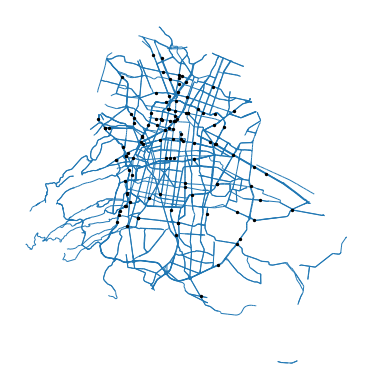

In [4]:
# radares: no tiene mucho chiste la vdd, lo que ya se espera que esté aquí
cameras = (
    gpd
    .read_file("data/fotocivicas-ubicacion-puntos/")
    .to_crs(CRS_METRICO)
)

fig, ax = plt.subplots(1,1,figsize=(4,4))
ax.set_axis_off()
cameras.plot(ax=ax, markersize=2, color='black', zorder=2)
vialidades.plot(ax=ax, linewidth=.7, zorder=1)
fig.tight_layout()
plt.show()

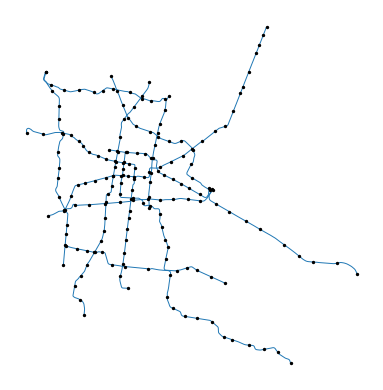

In [5]:
# estaciones del metro que me acabo de encontrar
# puta madre, están mucho mejor estas wey
# ojo: los dos archivos se llaman utm14n pero solo las líneas lo están;
# las estaciones vienen en grados, cada .prj declara lo suyo y to_crs las alinea
def arreglar_mojibake(s):
    """Deshace 'LÃ­nea' -> 'Línea'. Si ya está bien, lo deja igual."""
    if not isinstance(s, str):
        return s
    try:
        return s.encode("latin-1").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return s
        
def llave_estacion(s):
    """Clave de join: sin mojibake, sin acentos, sin guiones, en mayúsculas."""
    s = arreglar_mojibake(s)
    s = unicodedata.normalize("NFD", s)
    s = "".join(c for c in s if unicodedata.category(c) != "Mn")
    return " ".join(s.replace("-", " ").split()).upper()

def llave_linea(s):
    """La afluencia dice 'Línea 1' y el shapefile '01'."""
    s = llave_estacion(s).replace("LINEA ", "")
    return s.zfill(2) if s.isdigit() else s   # '1' -> '01'; 'A' y 'B' se quedan


estaciones = (
    gpd
    .read_file("data/stcmetro_shp/estaciones/")
    .to_crs(CRS_METRICO)
    .assign(
        linea_key=lambda x: x.LINEA.map(llave_linea),
        estacion_key=lambda x: x.NOMBRE.map(llave_estacion)
    )
    [["linea_key", "estacion_key", "geometry"]]
)
vias = (
    gpd
    .read_file("data/stcmetro_shp/lineas/")
    .to_crs(CRS_METRICO)
)


fig, ax = plt.subplots(1,1,figsize=(4,4))
ax.set_axis_off()
estaciones.plot(ax=ax, markersize=2, color='black', zorder=2)
vias.plot(ax=ax, linewidth=.7, zorder=1)
fig.tight_layout()
plt.show()

In [6]:
# Datos de la afluencia en las estaciones del metro
# también estaban mal :OOOOO
afluencia = pd.read_csv("data/raw/raw-afluencia-metro.csv")

# Renombres donde las dos fuentes usan nombres distintos para la misma estación.
RENOMBRES = {
    "NINOS HEROES": "NINOS HEROES/PODER JUDICIAL CDMX",  # la estación se renombró
    "MIXIUHCA": "MIXHIUCA",                              # el shapefile trae la errata
}

afluencia = (
    afluencia
    .assign(
        linea_key=lambda x: x.linea.map(llave_linea),
        estacion_key=lambda x: x.estacion.map(llave_estacion).replace(RENOMBRES),
        fecha=lambda x: pd.to_datetime(x.fecha),
        before_treatment=lambda x: x.fecha < FECHA_INICIO
    )
    # el csv llega hasta 2026, no tiene caso arrastrar 16 años en cada groupby
    .query("@VENTANA_INICIO <= fecha <= @VENTANA_FIN")
    [["linea_key", "estacion_key", "fecha", "before_treatment", "afluencia"]]
)

# si un renombre futuro rompe el join, que truene aquí y no con nulos silenciosos
pares_afluencia = set(map(tuple, afluencia[["linea_key", "estacion_key"]].drop_duplicates().values))
pares_estaciones = set(map(tuple, estaciones[["linea_key", "estacion_key"]].drop_duplicates().values))
assert pares_afluencia <= pares_estaciones, sorted(pares_afluencia - pares_estaciones)

afluencia.head()

,linea_key,estacion_key,fecha,before_treatment,afluencia
449085,01,GOMEZ FARIAS,2016-04-22,True,41744
449086,01,ISABEL LA CATOLICA,2016-04-22,True,32444
449087,06,INSTITUTO DEL PETROLEO,2016-04-22,True,5463
449088,02,SAN ANTONIO ABAD,2016-04-22,True,31756
449089,08,CERRO DE LA ESTRELLA,2016-04-22,True,11971


In [7]:
# volumen vehicular mensual: el denominador para las tasas
volumen = (
    pd
    .read_parquet("data/volumen-total-mensual.parquet")
    .assign(before_treatment=lambda x: x.timestamp < FECHA_INICIO)
    # viene de 2015 a 2024, lo recorto igual que todo lo demás
    .query("@VENTANA_INICIO <= timestamp <= @VENTANA_FIN")
)

volumen.head(3)

,timestamp,volumen_mensual,before_treatment
16,2016-05-01,15517.130522,True
17,2016-06-01,15016.220080,True
18,2016-07-01,16743.696904,True
